<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_X_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Classical DDPM on Quark/Gluon Jet Images + Quantum Extension

**Dataset:** `QG_jets.npz` (same file as Task II)  
**What we do:** Convert particle jets → 2D images → train a classical DDPM → propose quantum extension.


In [1]:
!pip install torch torchvision numpy matplotlib scikit-learn tqdm scipy -q

In [2]:
import os
if not os.path.exists('QG_jets.npz'):
    !wget https://zenodo.org/record/3164691/files/QG_jets.npz
    print('Download complete!')
else:
    print('QG_jets.npz already present — skipping download.')

--2026-04-16 14:41:26--  https://zenodo.org/record/3164691/files/QG_jets.npz
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.103.118, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/3164691/files/QG_jets.npz [following]
--2026-04-16 14:41:26--  https://zenodo.org/records/3164691/files/QG_jets.npz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 106689379 (102M) [application/octet-stream]
Saving to: ‘QG_jets.npz’

QG_jets.npz         100%[===================>] 101.75M   826KB/s    in 1m 57s  

2026-04-16 14:43:24 (890 KB/s) - ‘QG_jets.npz’ saved [106689379/106689379]

Download complete!


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from scipy.stats import wasserstein_distance

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE   = 32
N_SAMPLES  = 8000
BATCH_SIZE = 64
EPOCHS     = 40
LR         = 2e-4
T          = 1000
CHANNELS   = 1
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device   : {DEVICE}')
print(f'Img size : {IMG_SIZE}x{IMG_SIZE}')
print(f'Timesteps: {T}')

Device   : cuda
Img size : 32x32
Timesteps: 1000


## Load Data

`QG_jets.npz` has shape `(100000, 139, 4)` — each jet has up to 139 particles with features `[pT, eta, phi, pid]`.

In [4]:
data  = np.load('QG_jets.npz', allow_pickle=True)
X_raw = data['X']   # (100000, 139, 4)
y_raw = data['y']   # (100000,)
print(f'X shape: {X_raw.shape}')
print(f'y shape: {y_raw.shape}')
print(f'Quarks: {int(y_raw.sum())}  |  Gluons: {int((y_raw==0).sum())}')

X shape: (100000, 139, 4)
y shape: (100000,)
Quarks: 50000  |  Gluons: 50000


## Convert Jets to 2D Images

We histogram each jet's particles in eta-phi space, weighting by pT. This is the standard **jet image** representation in HEP ML.

In [5]:
def jet_to_image(jet, size=32):
    """Convert one jet (139,4) -> pT image (size x size) via 2D histogram."""
    pT  = jet[:, 0]
    eta = jet[:, 1]
    phi = jet[:, 2]
    mask = pT > 0
    pT, eta, phi = pT[mask], eta[mask], phi[mask]
    img, _, _ = np.histogram2d(
        eta, phi, bins=size,
        range=[[-1.0, 1.0], [-1.0, 1.0]],
        weights=pT
    )
    return img.astype(np.float32)

# Balanced subset of quarks and gluons
half  = N_SAMPLES // 2
q_idx = np.where(y_raw == 1)[0][:half]
g_idx = np.where(y_raw == 0)[0][:half]
idx   = np.concatenate([q_idx, g_idx])
np.random.shuffle(idx)

print(f'Converting {N_SAMPLES} jets to {IMG_SIZE}x{IMG_SIZE} images...')
images = np.stack([jet_to_image(X_raw[i], IMG_SIZE) for i in tqdm(idx)], axis=0)
labels = y_raw[idx]
print(f'Done. images shape: {images.shape}')

Converting 8000 jets to 32x32 images...


100%|██████████| 8000/8000 [00:01<00:00, 7981.44it/s]


Done. images shape: (8000, 32, 32)


In [6]:
# Log-scale + normalise to [0,1] + scale to [-1,1] for DDPM
images_log  = np.log1p(images)
global_max  = images_log.max()
images_norm = images_log / (global_max + 1e-8)

X_tensor = torch.tensor(images_norm, dtype=torch.float32).unsqueeze(1)  # (N,1,32,32)
X_tensor = X_tensor * 2.0 - 1.0

print(f'Tensor shape : {X_tensor.shape}')
print(f'Value range  : [{X_tensor.min():.3f}, {X_tensor.max():.3f}]')

Tensor shape : torch.Size([8000, 1, 32, 32])
Value range  : [-1.000, 1.000]


## Visualise Jet Images

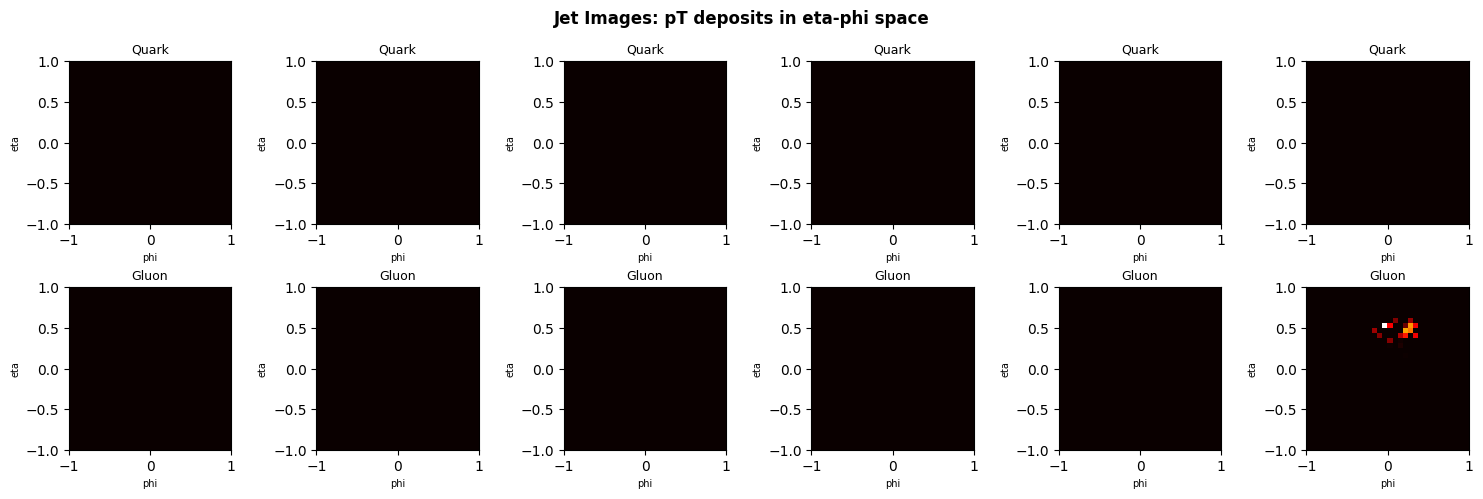

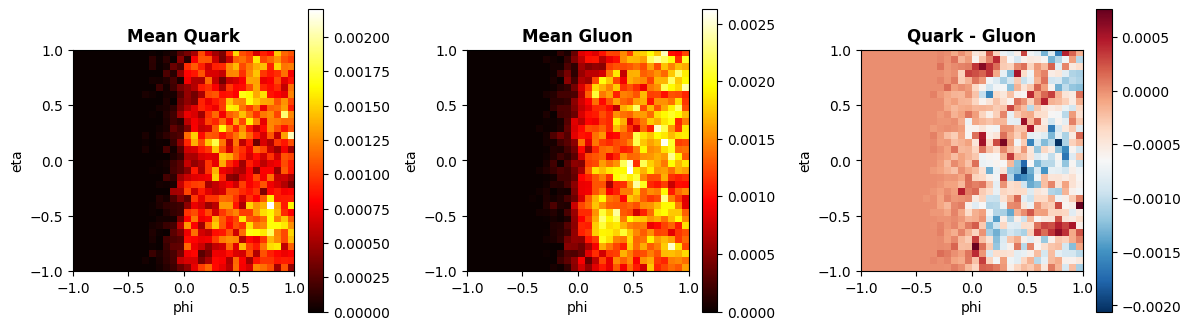

Quarks are collimated (narrow); gluons are broader.


In [7]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for row, (jlabel, jname) in enumerate([(1, 'Quark'), (0, 'Gluon')]):
    samples = X_tensor[labels == jlabel][:6]
    for col, img in enumerate(samples):
        disp = ((img[0] + 1) / 2).clamp(0, 1).numpy()
        axes[row, col].imshow(disp, cmap='hot', origin='lower', extent=[-1,1,-1,1])
        axes[row, col].set_title(jname, fontsize=9)
        axes[row, col].set_xlabel('phi', fontsize=7)
        axes[row, col].set_ylabel('eta', fontsize=7)
plt.suptitle('Jet Images: pT deposits in eta-phi space', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('jet_images.png', dpi=120, bbox_inches='tight')
plt.show()

# Mean images
mean_q = ((X_tensor[labels==1]+1)/2).mean(0)[0].numpy()
mean_g = ((X_tensor[labels==0]+1)/2).mean(0)[0].numpy()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, img, title, cmap in zip(axes,
    [mean_q, mean_g, mean_q-mean_g],
    ['Mean Quark', 'Mean Gluon', 'Quark - Gluon'],
    ['hot', 'hot', 'RdBu_r']):
    im = ax.imshow(img, cmap=cmap, origin='lower', extent=[-1,1,-1,1])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('phi'); ax.set_ylabel('eta')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('mean_jets.png', dpi=120, bbox_inches='tight')
plt.show()
print('Quarks are collimated (narrow); gluons are broader.')

## DDPM Forward Process — Cosine Noise Schedule

$$q(x_t|x_{t-1}) = \mathcal{N}(x_t;\,\sqrt{1-\beta_t}\,x_{t-1},\,\beta_t I)$$

Direct sampling at any $t$ (reparameterisation trick):
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\quad \varepsilon\sim\mathcal{N}(0,I)$$

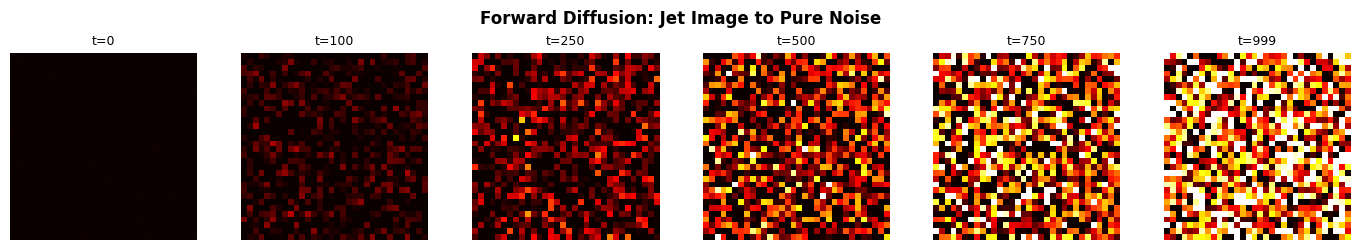

In [8]:
class DiffusionSchedule:
    def __init__(self, T=1000, s=0.008, device='cpu'):
        self.T = T
        self.device = device
        steps = torch.arange(T+1, dtype=torch.float64)
        f  = torch.cos(((steps/T)+s)/(1+s)*math.pi/2)**2
        ab = f / f[0]
        betas  = (1 - ab[1:]/ab[:-1]).clamp(0, 0.999).float()
        alphas = 1.0 - betas
        ab     = torch.cumprod(alphas, 0)
        self.betas      = betas.to(device)
        self.alphas     = alphas.to(device)
        self.alphas_bar = ab.to(device)
        self.sqrt_ab    = ab.sqrt().to(device)
        self.sqrt_1ab   = (1-ab).sqrt().to(device)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sa  = self.sqrt_ab[t].view(-1,1,1,1)
        s1a = self.sqrt_1ab[t].view(-1,1,1,1)
        return sa*x0 + s1a*noise, noise

schedule = DiffusionSchedule(T=T, device=DEVICE)

# Visualise forward noising
sample_img = X_tensor[0:1].to(DEVICE)
t_vals = [0, 100, 250, 500, 750, 999]
fig, axs = plt.subplots(1, len(t_vals), figsize=(14, 2.5))
for ax, tv in zip(axs, t_vals):
    xt, _ = schedule.q_sample(sample_img, torch.tensor([tv], device=DEVICE))
    ax.imshow(xt[0,0].cpu().numpy(), cmap='hot', vmin=-1, vmax=1)
    ax.set_title(f't={tv}', fontsize=9); ax.axis('off')
plt.suptitle('Forward Diffusion: Jet Image to Pure Noise', fontweight='bold')
plt.tight_layout()
plt.savefig('forward_diffusion.png', dpi=120, bbox_inches='tight')
plt.show()

## U-Net Denoiser Architecture

The U-Net $\varepsilon_\theta(x_t,t)$ predicts the noise added at each step.

Key components:
- **Sinusoidal time embedding** — encodes timestep $t$, injected at every ResBlock via FiLM (scale + shift)
- **ResBlocks with GroupNorm** — stable training
- **Skip connections** — encoder features passed to decoder
- **Self-attention at bottleneck** — captures global jet structure

In [9]:
class SinPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        h = self.dim // 2
        f = torch.exp(-math.log(10000)*torch.arange(h, device=t.device)/(h-1))
        a = t[:,None].float()*f[None]
        return torch.cat([a.sin(), a.cos()], -1)

class ResBlock(nn.Module):
    def __init__(self, ic, oc, td):
        super().__init__()
        g = lambda c: min(8, c)
        self.n1 = nn.GroupNorm(g(ic), ic)
        self.c1 = nn.Conv2d(ic, oc, 3, padding=1)
        self.n2 = nn.GroupNorm(g(oc), oc)
        self.c2 = nn.Conv2d(oc, oc, 3, padding=1)
        self.tp = nn.Sequential(nn.SiLU(), nn.Linear(td, oc*2))
        self.sk = nn.Conv2d(ic, oc, 1) if ic != oc else nn.Identity()
    def forward(self, x, te):
        h = self.c1(F.silu(self.n1(x)))
        sc, sh = self.tp(te)[:,:,None,None].chunk(2, 1)
        h = self.n2(h)*(1+sc)+sh
        return self.c2(F.silu(h)) + self.sk(x)

class Attn(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.n = nn.GroupNorm(min(8,ch), ch)
        self.a = nn.MultiheadAttention(ch, 4, batch_first=True)
    def forward(self, x):
        B,C,H,W = x.shape
        h = self.n(x).view(B,C,-1).permute(0,2,1)
        h,_ = self.a(h,h,h)
        return x + h.permute(0,2,1).view(B,C,H,W)

class UNet(nn.Module):
    def __init__(self, in_ch=1, base=64, td=256):
        super().__init__()
        self.temb = nn.Sequential(SinPosEmb(base), nn.Linear(base,td), nn.SiLU(), nn.Linear(td,td))
        self.e0  = nn.Conv2d(in_ch, base, 3, padding=1)
        self.e1  = ResBlock(base,   base*2, td)
        self.d1  = nn.Conv2d(base*2, base*2, 4, 2, 1)
        self.e2  = ResBlock(base*2, base*4, td)
        self.d2  = nn.Conv2d(base*4, base*4, 4, 2, 1)
        self.m1  = ResBlock(base*4, base*4, td)
        self.at  = Attn(base*4)
        self.m2  = ResBlock(base*4, base*4, td)
        self.u2  = nn.ConvTranspose2d(base*4, base*2, 4, 2, 1)
        self.r2  = ResBlock(base*8, base*2, td)
        self.u1  = nn.ConvTranspose2d(base*2, base,   4, 2, 1)
        self.r1  = ResBlock(base*4, base,   td)
        self.out = nn.Sequential(nn.GroupNorm(8,base), nn.SiLU(), nn.Conv2d(base, in_ch, 3, padding=1))

    def forward(self, x, t):
        te  = self.temb(t)
        e0  = self.e0(x)
        e1  = self.e1(e0, te)
        e1d = self.d1(e1)
        e2  = self.e2(e1d, te)
        e2d = self.d2(e2)
        m   = self.m2(self.at(self.m1(e2d, te)), te)
        d2  = self.r2(torch.cat([self.u2(m), e2, e1d], 1), te)
        d1  = self.r1(torch.cat([self.u1(d2), e1, e0], 1), te)
        return self.out(d1)

model  = UNet(in_ch=CHANNELS, base=64, td=256).to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters: {params:,}')

with torch.no_grad():
    _x = torch.randn(2, CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _t = torch.randint(0, T, (2,)).to(DEVICE)
    print(f'Output shape: {model(_x, _t).shape}  (expected [2, 1, 32, 32])  OK')

U-Net parameters: 7,390,913
Output shape: torch.Size([2, 1, 32, 32])  (expected [2, 1, 32, 32])  OK


## Training

Simplified ELBO loss (Ho et al. 2020):
$$\mathcal{L} = \mathbb{E}_{t,x_0,\varepsilon}\left[\|\varepsilon - \varepsilon_\theta(x_t,t)\|^2\right]$$

In [10]:
class JetDS(Dataset):
    def __init__(self, t): self.d = t
    def __len__(self): return len(self.d)
    def __getitem__(self, i): return self.d[i]

split        = int(0.9 * len(X_tensor))
train_loader = DataLoader(JetDS(X_tensor[:split]), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(JetDS(X_tensor[split:]), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {split}  |  Val: {len(X_tensor)-split}')

opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

def loss_fn(batch):
    x0 = batch.to(DEVICE)
    t  = torch.randint(0, T, (x0.shape[0],), device=DEVICE)
    xt, noise = schedule.q_sample(x0, t)
    return F.mse_loss(model(xt, t), noise)

train_losses, val_losses = [], []
print('Training...\n')
for epoch in range(1, EPOCHS+1):
    model.train()
    tl = 0.0
    for b in train_loader:
        opt.zero_grad()
        l = loss_fn(b); l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); tl += l.item()
    train_losses.append(tl / len(train_loader))

    model.eval(); vl = 0.0
    with torch.no_grad():
        for b in val_loader: vl += loss_fn(b).item()
    val_losses.append(vl / len(val_loader))
    sched.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  Train: {train_losses[-1]:.5f}  Val: {val_losses[-1]:.5f}')
print('\nDone!')

Train: 7200  |  Val: 800
Training...

Epoch   1/40  Train: 0.05977  Val: 0.01200
Epoch   5/40  Train: 0.00504  Val: 0.00425
Epoch  10/40  Train: 0.00357  Val: 0.00471
Epoch  15/40  Train: 0.00255  Val: 0.00357
Epoch  20/40  Train: 0.00234  Val: 0.00297
Epoch  25/40  Train: 0.00191  Val: 0.00228
Epoch  30/40  Train: 0.00179  Val: 0.00223
Epoch  35/40  Train: 0.00160  Val: 0.00160
Epoch  40/40  Train: 0.00165  Val: 0.00158

Done!


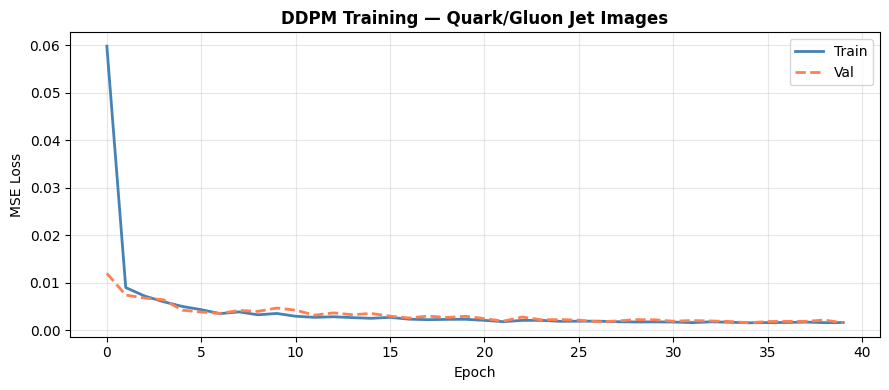

In [11]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(train_losses, label='Train', color='steelblue', lw=2)
ax.plot(val_losses,   label='Val',   color='coral',     lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('DDPM Training — Quark/Gluon Jet Images', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Sampling

Reverse process from $x_T\sim\mathcal{N}(0,I)$:
$$x_{t-1}=\frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\varepsilon_\theta(x_t,t)\right)+\sqrt{\beta_t}\,z$$

In [12]:
@torch.no_grad()
def sample(model, sch, n=16, size=32, ch=1, device='cpu', steps=200):
    model.eval()
    x = torch.randn(n, ch, size, size, device=device)
    stride = max(sch.T // steps, 1)
    ts = list(range(0, sch.T, stride))[::-1]
    for tv in tqdm(ts, desc='Sampling', leave=False):
        tb  = torch.full((n,), tv, device=device, dtype=torch.long)
        eps = model(x, tb)
        ab  = sch.alphas_bar[tv]
        x0p = ((x - (1-ab).sqrt()*eps) / ab.sqrt()).clamp(-1, 1)
        x   = ab.sqrt()*x0p + (1-ab).sqrt()*torch.randn_like(x) if tv > 0 else x0p
    return x.cpu()

generated = sample(model, schedule, n=16, size=IMG_SIZE, ch=CHANNELS, device=DEVICE, steps=200)
print(f'Generated: {generated.shape}  range [{generated.min():.3f}, {generated.max():.3f}]')

Generated: torch.Size([16, 1, 32, 32])  range [-1.000, -0.948]


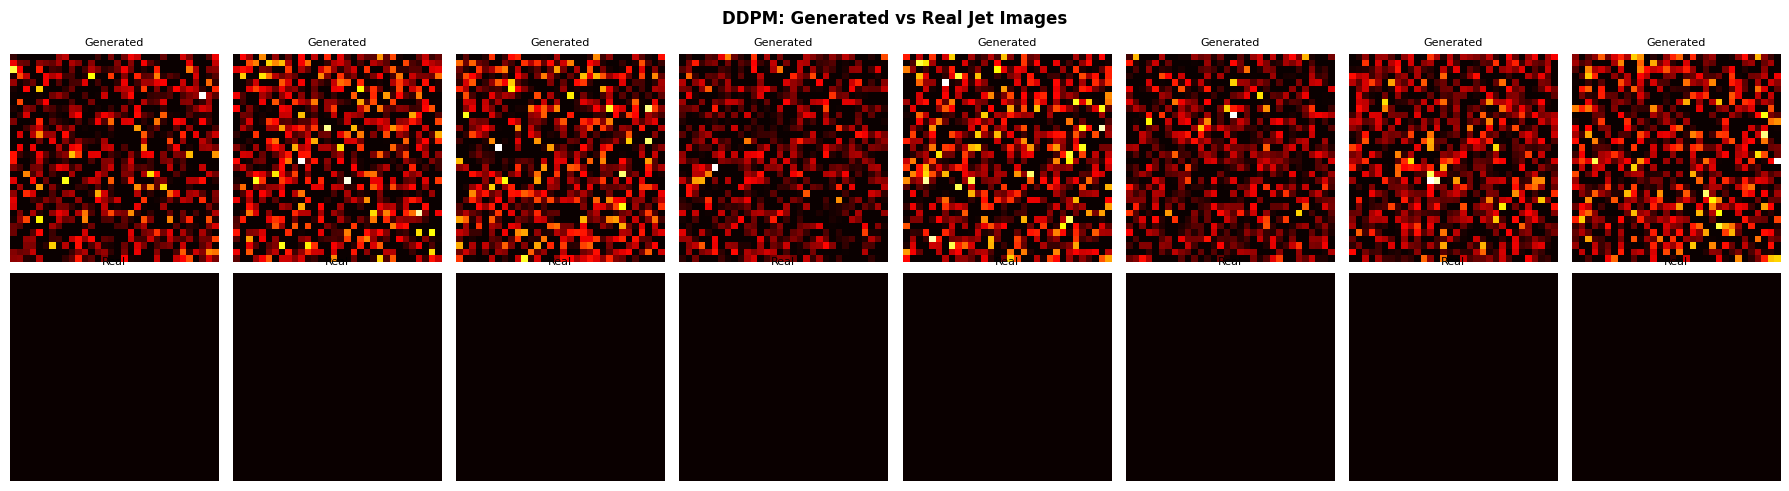

In [13]:
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    gen  = ((generated[i,0]+1)/2).clamp(0,1).numpy()
    real = ((X_tensor[i,0]+1)/2).clamp(0,1).numpy()
    axes[0,i].imshow(gen,  cmap='hot', origin='lower'); axes[0,i].set_title('Generated', fontsize=8); axes[0,i].axis('off')
    axes[1,i].imshow(real, cmap='hot', origin='lower'); axes[1,i].set_title('Real',      fontsize=8); axes[1,i].axis('off')
plt.suptitle('DDPM: Generated vs Real Jet Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('generated_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluation — Wasserstein Distance

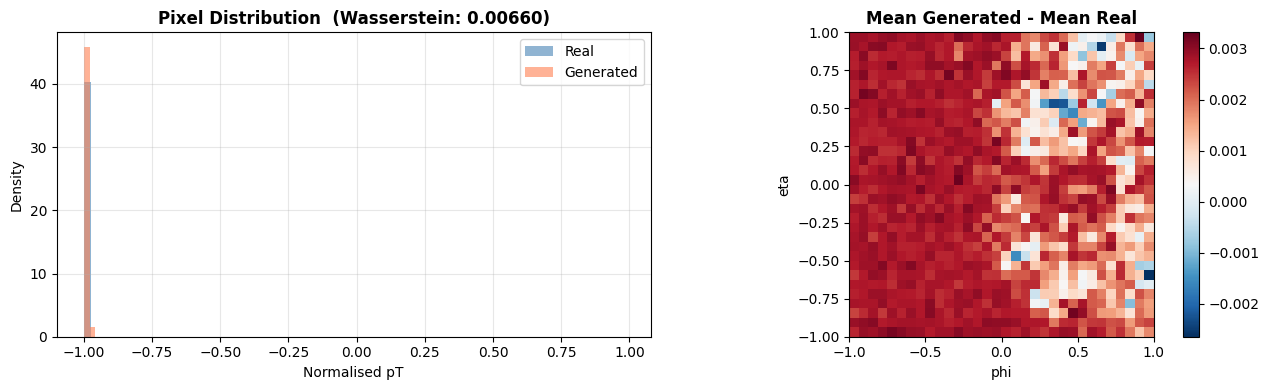

Wasserstein distance: 0.00660  (lower = more similar)


In [14]:
gen_large  = sample(model, schedule, n=512, size=IMG_SIZE, ch=CHANNELS, device=DEVICE, steps=200)
real_flat  = X_tensor[:512,0].numpy().flatten()
gen_flat   = gen_large[:,0].numpy().flatten()
wd         = wasserstein_distance(real_flat, gen_flat)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(real_flat, bins=80, alpha=0.6, color='steelblue', density=True, label='Real')
axes[0].hist(gen_flat,  bins=80, alpha=0.6, color='coral',     density=True, label='Generated')
axes[0].set_title(f'Pixel Distribution  (Wasserstein: {wd:.5f})', fontweight='bold')
axes[0].set_xlabel('Normalised pT'); axes[0].set_ylabel('Density')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

diff = ((gen_large[:,0]+1)/2).mean(0).numpy() - ((X_tensor[:512,0]+1)/2).mean(0).numpy()
im   = axes[1].imshow(diff, cmap='RdBu_r', origin='lower', extent=[-1,1,-1,1])
axes[1].set_title('Mean Generated - Mean Real', fontweight='bold')
axes[1].set_xlabel('phi'); axes[1].set_ylabel('eta')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig('evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Wasserstein distance: {wd:.5f}  (lower = more similar)')

In [15]:
torch.save({
    'model_state':  model.state_dict(),
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'config': {'IMG_SIZE': IMG_SIZE, 'T': T, 'EPOCHS': EPOCHS}
}, 'ddpm_jet.pt')

print('='*50)
print('RESULTS SUMMARY')
print('='*50)
print(f'  Parameters   : {params:,}')
print(f'  Train loss   : {train_losses[-1]:.5f}')
print(f'  Val loss     : {val_losses[-1]:.5f}')
print(f'  Wasserstein  : {wd:.5f}')
print('='*50)

RESULTS SUMMARY
  Parameters   : 7,390,913
  Train loss   : 0.00165
  Val loss     : 0.00158
  Wasserstein  : 0.00660


---
## Quantum Diffusion Extension

### Motivation
Classical DDPMs use Gaussian noise and large CNNs (U-Net). We can replace either or both with quantum components. Three approaches are described below, ordered by near-term practicality.

---

### Approach 1 — Hybrid Quantum-Classical DDPM (NISQ-ready today)

Keep the classical forward process and classical U-Net, but **replace the 8x8 bottleneck with a Parametrised Quantum Circuit (PQC)**.

```
Noisy jet image x_t  (1x32x32)
        |
 [Classical Encoder]   32->16->8  (ResBlocks + downsampling)
        |
 [Quantum Bottleneck]
 +------------------------------------------+
 |  Linear projection  -> n_qubits values   |
 |  Angle embedding:   R_y(x_i) per qubit   |
 |  Entangling PQC:    Rot + CNOT layers    |
 |  Time conditioning: t -> extra angles    |
 |  Measure:           expectation <Z_i>    |
 |  Linear projection  -> back to 256x8x8  |
 +------------------------------------------+
        |
 [Classical Decoder]   8->16->32  (ResBlocks + upsampling + skips)
        |
 Predicted noise  (1x32x32)
```

**Gradients** through the PQC use the parameter-shift rule:
$$\frac{\partial\mathcal{L}}{\partial\theta_k} = \frac{1}{2}\left[\mathcal{L}(\theta_k+\frac{\pi}{2}) - \mathcal{L}(\theta_k-\frac{\pi}{2})\right]$$

**Implementation:** PennyLane `qml.qnn.TorchLayer` — drop-in replacement for the bottleneck nn.Module.

---

### Approach 2 — Fully Quantum DDPM (QuDDPM, Zhang et al. 2024)

Both forward and reverse processes are fully quantum.

**Forward — Quantum Scrambling Circuit (QSC):**
```
x_0 -> angle embed -> |psi_0>
|psi_0> -> [U_1] -> [U_2] -> ... -> [U_T] -> rho_T = I/2^n
             random unitaries = quantum noise (maximally mixed state)
```

**Reverse — VQC Denoiser:**
```
rho_T -> [V_theta(T)] -> [measure+reset] -> ... -> [V_theta(1)] -> |psi_hat_0> -> x_hat_0
           PQC              ancilla qubit             PQC
```

Non-unitarity (needed to reduce entropy) is achieved via **ancilla qubits** that are measured and reset.  
**Barren plateau fix:** Train each reverse step independently before chaining.

---

### Approach 3 — Haar Wavelet Quantum Diffusion (physics-motivated)

Best match for jet images (Baidachna et al. 2024):

```
Jet image (32x32)
    |   Haar wavelet transform  (unitary -> directly quantum)
    v
Wavelet patches  (e.g. 4x4 tiles)
    |   Angle embed each patch -> n_qubits
    v
Quantum state per patch |psi_patch>
    |
    +-- Forward:  Haar-scrambling  (respects phi-rotation symmetry of jets)
    |
    +-- Reverse:  PQC per patch -> stitch -> generated jet image
```

Haar wavelets are unitary transforms that map directly to quantum gates, and jets have natural multi-scale structure (collimated core + diffuse periphery) that wavelets capture efficiently.

---

### Comparison Table

| | Classical DDPM | Hybrid (Approach 1) | Fully Quantum (Approach 2) |
|---|---|---|---|
| Forward noise | Gaussian | Gaussian | Quantum scrambling |
| Denoiser | U-Net | U-Net + PQC bottleneck | VQC only |
| Hardware | GPU | GPU + QPU (small) | QPU |
| Qubits needed | None | 6-12 | n x log(32x32) |
| Feasibility | Done (above) | NISQ-ready | Research stage |

### Key Challenges
- **Encoding:** 32x32 image needs 10 qubits min for amplitude embedding — use 4x4 patch encoding (4 qubits) instead
- **Barren plateaus:** Use shallow circuits + local loss functions
- **Simulation cost:** O(2^n) — limits to ~20-30 qubits on classical simulators
- **Measurement shots:** Many circuit evaluations needed per gradient step

### References
1. Ho et al. (2020). *Denoising Diffusion Probabilistic Models.* NeurIPS.
2. Nichol & Dhariwal (2021). *Improved DDPM.* ICML.
3. Zhang et al. (2024). *Generative Quantum ML via DDPM (QuDDPM).* Phys. Rev. Lett. 132, 100602.
4. Parigi et al. (2024). *Quantum-Noise-Driven Generative Diffusion Models.* Advanced Quantum Tech.
5. Baidachna et al. (2024). *Quantum Diffusion Model for Quark/Gluon Jet Generation.* arXiv:2412.21082.
